Dataset shape: (100, 10, 144)
Euclidean: EER = 11.48% | d' = 1.762
Cosine: EER = 8.36% | d' = 1.926


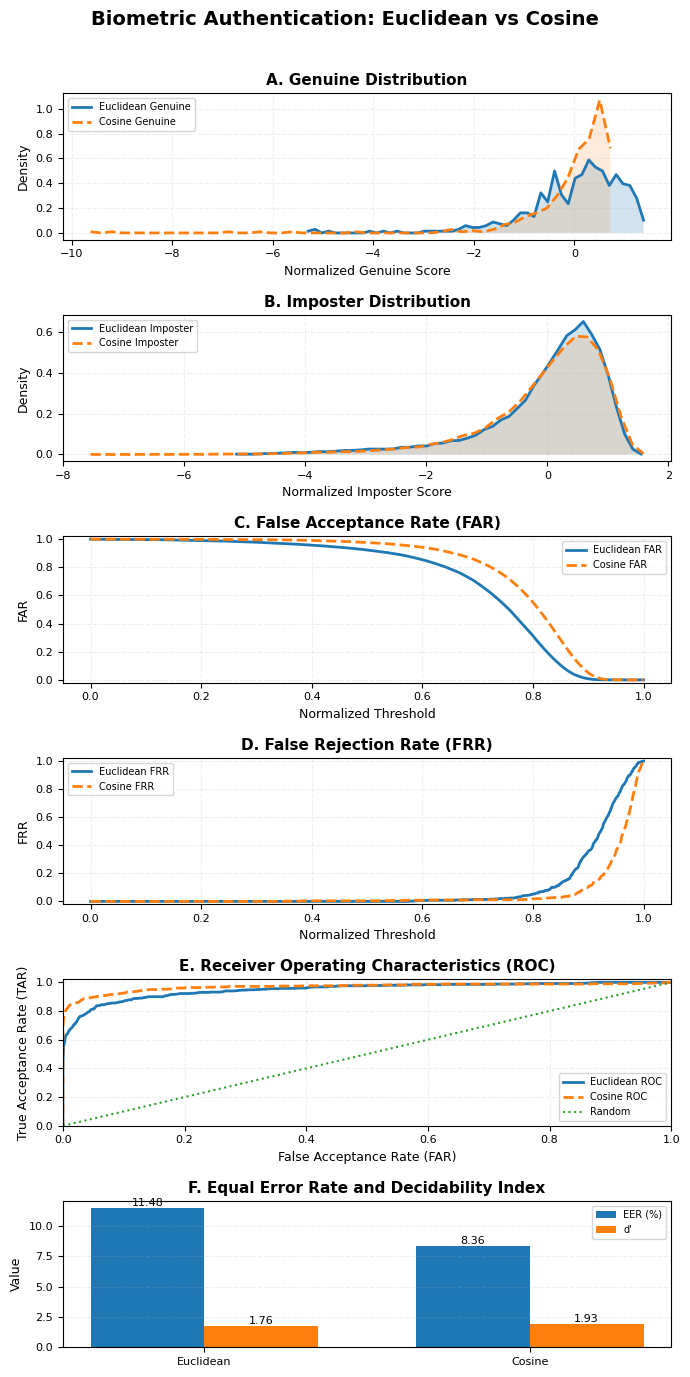


========== SUMMARY ==========
             EER (%)  Decidability Index (d')
Euclidean  11.484848                 1.762246
Cosine      8.359596                 1.925934

Best metric based on EER: Cosine

Combined graph saved at:
/content/outputs/BIOMETRIC_EVALUATION_A_TO_F.png

Summary CSV saved at:
/content/outputs/summary_metrics.csv

Done!


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean, cosine

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "/content/biomet_data.csv"
OUT_DIR = "/content/outputs"

os.makedirs(OUT_DIR, exist_ok=True)

N_ENROLL = 5
N_TEST = 5


# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(
    CSV_PATH,
    sep="\t",
    header=None
)

# Remove empty columns and incomplete rows
df = (
    df.dropna(axis=1, how="all")
      .dropna(axis=0)
      .reset_index(drop=True)
)

# Features x samples -> samples x features
data = df.T.values

n_samples, n_features = data.shape

if n_samples % 10 != 0:
    raise ValueError(
        f"{n_samples} samples cannot be divided into groups of 10."
    )

n_users = n_samples // 10

features = data.reshape(
    n_users,
    10,
    n_features
)

print("Dataset shape:", features.shape)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================
train = features[:, :N_ENROLL, :]
test = features[:, N_ENROLL:N_ENROLL + N_TEST, :]

# One template for each user
templates = train.mean(axis=1)


# ============================================================
# SCORE FUNCTIONS
# ============================================================
def get_scores(metric):

    genuine = []
    imposter = []

    for u in range(n_users):

        for s in range(N_TEST):

            x = test[u, s]

            for t in range(n_users):

                if metric == "Euclidean":

                    # Negative Euclidean distance
                    # Larger score = more similar
                    score = -euclidean(
                        x,
                        templates[t]
                    )

                else:

                    # Cosine similarity
                    score = 1 - cosine(
                        x,
                        templates[t]
                    )

                if u == t:
                    genuine.append(score)
                else:
                    imposter.append(score)

    return (
        np.array(genuine),
        np.array(imposter)
    )


# ============================================================
# FAR / FRR / EER / d'
# ============================================================
def calculate(genuine, imposter):

    scores = np.r_[
        genuine,
        imposter
    ]

    thresholds = np.linspace(
        scores.min(),
        scores.max(),
        1000
    )

    # False Acceptance Rate
    far = np.array([
        (imposter >= t).mean()
        for t in thresholds
    ])

    # False Rejection Rate
    frr = np.array([
        (genuine < t).mean()
        for t in thresholds
    ])

    # Equal Error Rate
    i = np.argmin(
        np.abs(far - frr)
    )

    eer = (
        far[i] +
        frr[i]
    ) / 2

    # Decidability Index
    d_prime = abs(
        genuine.mean() -
        imposter.mean()
    ) / np.sqrt(
        (
            genuine.var() +
            imposter.var()
        ) / 2
    )

    return (
        thresholds,
        far,
        frr,
        eer,
        d_prime
    )


# ============================================================
# CALCULATE BOTH METRICS
# ============================================================
results = {}
data_all = {}

for metric in [
    "Euclidean",
    "Cosine"
]:

    genuine, imposter = get_scores(
        metric
    )

    (
        thresholds,
        far,
        frr,
        eer,
        d_prime
    ) = calculate(
        genuine,
        imposter
    )

    results[metric] = [
        eer * 100,
        d_prime
    ]

    data_all[metric] = {
        "genuine": genuine,
        "imposter": imposter,
        "thresholds": thresholds,
        "far": far,
        "frr": frr
    }

    print(
        f"{metric}: "
        f"EER = {eer * 100:.2f}% | "
        f"d' = {d_prime:.3f}"
    )


# ============================================================
# SINGLE VERTICAL FIGURE
# A -> F
# ============================================================
fig, ax = plt.subplots(
    6,
    1,
    figsize=(7, 14)
)


# ============================================================
# A. GENUINE DISTRIBUTION
# ============================================================
for metric, linestyle, alpha in [
    ("Euclidean", "-", 0.20),
    ("Cosine", "--", 0.15)
]:

    genuine = data_all[metric]["genuine"]

    mean = genuine.mean()
    std = genuine.std()

    genuine_norm = (
        genuine - mean
    ) / std

    density, bins = np.histogram(
        genuine_norm,
        bins=50,
        density=True
    )

    centers = (
        bins[:-1] +
        bins[1:]
    ) / 2

    ax[0].plot(
        centers,
        density,
        linestyle=linestyle,
        linewidth=2,
        label=f"{metric} Genuine"
    )

    ax[0].fill_between(
        centers,
        density,
        alpha=alpha
    )


ax[0].set_title(
    "A. Genuine Distribution",
    fontsize=11,
    fontweight="bold"
)

ax[0].set_xlabel(
    "Normalized Genuine Score",
    fontsize=9
)

ax[0].set_ylabel(
    "Density",
    fontsize=9
)

ax[0].tick_params(
    labelsize=8
)

ax[0].legend(
    fontsize=7
)

ax[0].grid(
    alpha=0.2,
    linestyle="--"
)


# ============================================================
# B. IMPOSTER DISTRIBUTION
# ============================================================
for metric, linestyle, alpha in [
    ("Euclidean", "-", 0.20),
    ("Cosine", "--", 0.15)
]:

    imposter = data_all[metric]["imposter"]

    mean = imposter.mean()
    std = imposter.std()

    imposter_norm = (
        imposter - mean
    ) / std

    density, bins = np.histogram(
        imposter_norm,
        bins=50,
        density=True
    )

    centers = (
        bins[:-1] +
        bins[1:]
    ) / 2

    ax[1].plot(
        centers,
        density,
        linestyle=linestyle,
        linewidth=2,
        label=f"{metric} Imposter"
    )

    ax[1].fill_between(
        centers,
        density,
        alpha=alpha
    )


ax[1].set_title(
    "B. Imposter Distribution",
    fontsize=11,
    fontweight="bold"
)

ax[1].set_xlabel(
    "Normalized Imposter Score",
    fontsize=9
)

ax[1].set_ylabel(
    "Density",
    fontsize=9
)

ax[1].tick_params(
    labelsize=8
)

ax[1].legend(
    fontsize=7
)

ax[1].grid(
    alpha=0.2,
    linestyle="--"
)


# ============================================================
# C. FAR PLOT
# ============================================================
for metric, linestyle in [
    ("Euclidean", "-"),
    ("Cosine", "--")
]:

    thresholds = data_all[metric]["thresholds"]
    far = data_all[metric]["far"]

    threshold_norm = (
        thresholds - thresholds.min()
    ) / (
        thresholds.max() -
        thresholds.min()
    )

    ax[2].plot(
        threshold_norm,
        far,
        linestyle=linestyle,
        linewidth=2,
        label=f"{metric} FAR"
    )


ax[2].set_title(
    "C. False Acceptance Rate (FAR)",
    fontsize=11,
    fontweight="bold"
)

ax[2].set_xlabel(
    "Normalized Threshold",
    fontsize=9
)

ax[2].set_ylabel(
    "FAR",
    fontsize=9
)

ax[2].set_ylim(
    -0.02,
    1.02
)

ax[2].tick_params(
    labelsize=8
)

ax[2].legend(
    fontsize=7
)

ax[2].grid(
    alpha=0.2,
    linestyle="--"
)


# ============================================================
# D. FRR PLOT
# ============================================================
for metric, linestyle in [
    ("Euclidean", "-"),
    ("Cosine", "--")
]:

    thresholds = data_all[metric]["thresholds"]
    frr = data_all[metric]["frr"]

    threshold_norm = (
        thresholds - thresholds.min()
    ) / (
        thresholds.max() -
        thresholds.min()
    )

    ax[3].plot(
        threshold_norm,
        frr,
        linestyle=linestyle,
        linewidth=2,
        label=f"{metric} FRR"
    )


ax[3].set_title(
    "D. False Rejection Rate (FRR)",
    fontsize=11,
    fontweight="bold"
)

ax[3].set_xlabel(
    "Normalized Threshold",
    fontsize=9
)

ax[3].set_ylabel(
    "FRR",
    fontsize=9
)

ax[3].set_ylim(
    -0.02,
    1.02
)

ax[3].tick_params(
    labelsize=8
)

ax[3].legend(
    fontsize=7
)

ax[3].grid(
    alpha=0.2,
    linestyle="--"
)


# ============================================================
# E. RECEIVER OPERATING CHARACTERISTICS
# ============================================================
for metric, linestyle in [
    ("Euclidean", "-"),
    ("Cosine", "--")
]:

    far = data_all[metric]["far"]
    frr = data_all[metric]["frr"]

    # True Acceptance Rate
    tar = 1 - frr

    ax[4].plot(
        far,
        tar,
        linestyle=linestyle,
        linewidth=2,
        label=f"{metric} ROC"
    )


# Random classifier
ax[4].plot(
    [0, 1],
    [0, 1],
    ":",
    linewidth=1.5,
    label="Random"
)


ax[4].set_title(
    "E. Receiver Operating Characteristics (ROC)",
    fontsize=11,
    fontweight="bold"
)

ax[4].set_xlabel(
    "False Acceptance Rate (FAR)",
    fontsize=9
)

ax[4].set_ylabel(
    "True Acceptance Rate (TAR)",
    fontsize=9
)

ax[4].set_xlim(
    0,
    1
)

ax[4].set_ylim(
    0,
    1.02
)

ax[4].tick_params(
    labelsize=8
)

ax[4].legend(
    fontsize=7
)

ax[4].grid(
    alpha=0.2,
    linestyle="--"
)


# ============================================================
# F. EER AND DECIDABILITY INDEX
# ============================================================
metrics = [
    "Euclidean",
    "Cosine"
]

x = np.arange(
    len(metrics)
)

width = 0.35

eer_values = [
    results[m][0]
    for m in metrics
]

d_values = [
    results[m][1]
    for m in metrics
]


# EER bars
bars1 = ax[5].bar(
    x - width / 2,
    eer_values,
    width,
    label="EER (%)"
)

# d' bars
bars2 = ax[5].bar(
    x + width / 2,
    d_values,
    width,
    label="d'"
)


ax[5].set_title(
    "F. Equal Error Rate and Decidability Index",
    fontsize=11,
    fontweight="bold"
)

ax[5].set_xticks(
    x
)

ax[5].set_xticklabels(
    metrics,
    fontsize=9
)

ax[5].set_ylabel(
    "Value",
    fontsize=9
)

ax[5].tick_params(
    labelsize=8
)

ax[5].legend(
    fontsize=7
)

ax[5].grid(
    axis="y",
    alpha=0.2,
    linestyle="--"
)


# Add values above bars
for bars in [
    bars1,
    bars2
]:

    for bar in bars:

        value = bar.get_height()

        ax[5].text(
            bar.get_x() +
            bar.get_width() / 2,
            value,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )


# ============================================================
# MAIN TITLE
# ============================================================
plt.suptitle(
    "Biometric Authentication: Euclidean vs Cosine",
    fontsize=14,
    fontweight="bold"
)


# ============================================================
# LAYOUT
# ============================================================
plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.97
    ],
    h_pad=1.2
)


# ============================================================
# SAVE ONE SINGLE IMAGE
# ============================================================
path = os.path.join(
    OUT_DIR,
    "BIOMETRIC_EVALUATION_A_TO_F.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SUMMARY TABLE
# ============================================================
summary = pd.DataFrame(
    results,
    index=[
        "EER (%)",
        "Decidability Index (d')"
    ]
).T

summary_path = os.path.join(
    OUT_DIR,
    "summary_metrics.csv"
)

summary.to_csv(
    summary_path
)


# ============================================================
# PRINT RESULTS
# ============================================================
print("\n========== SUMMARY ==========")
print(summary)

best = summary[
    "EER (%)"
].idxmin()

print(
    f"\nBest metric based on EER: {best}"
)

print(
    f"\nCombined graph saved at:\n{path}"
)

print(
    f"\nSummary CSV saved at:\n{summary_path}"
)

print("\nDone!")